# Model Selection 
- In GPR7 we removed the outliers from the training data.
- Unfortunately, this yielded no improvements in the performance of the modelling.
- That was with a model with a standard k = 3.
- To try improve performance, here we will:
    - Try many models for the same data and compare using validation performance and Occam penalty.
    - Try several stochastic variations for q.

In [15]:
# Importing and data hopo hopo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from astropy.time import Time
from astropy.timeseries import LombScargle

from scipy.signal import find_peaks
from scipy.optimize import curve_fit, minimize

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.LSP_peaks import fit_peaks, set_period_axes
from helpers.df_ops import prepare_df, split_df
from helpers.priors import find_classify_signals, get_priors


# Individual stars
raw_HD81809 = pd.read_csv(r"../../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
raw_HD160346 = pd.read_csv(r"../../Data/benchmark/HD160346_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
raw_HD201091 =pd.read_csv(r"../../Data/benchmark/HD201091_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)

data_HD81809 = prepare_df(raw_HD81809)
data_HD160346 = prepare_df(raw_HD160346)
data_HD201091 = prepare_df(raw_HD201091)

train_HD81809,  valid_HD81809,  test_HD81809  = split_df(data_HD81809)
train_HD160346, valid_HD160346, test_HD160346 = split_df(data_HD160346)
train_HD201091, valid_HD201091, test_HD201091 = split_df(data_HD201091)


C:\Users\Joey\AppData\Local\Temp\ipykernel_15868\2370008255.py:29: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_HD81809 = pd.read_csv(r"../../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
C:\Users\Joey\AppData\Local\Temp\ipykernel_15868\2370008255.py:30: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_HD160346 = pd.read_csv(r"../../Data/benchmark/HD160346_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
C:\Users\Joey\AppData\Local\Temp\ipykernel_15868\2370008255.py:31: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support rege

In [16]:
def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    '''
    Calculates the NLL of a set of parameters for a local gp
    '''
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

In [17]:
def clean_df(train_df, tol = 3, plot = True, verbose = True):
    '''
    This uses a median absolute deviance filter to remove any crazy outliers in the training data.

    Returns a df with the outliers removed.
    If plot, plots the removed values.
    If verbose, states number of removed values.
    '''
    med = train_df['sind'].median()
    mad = (train_df['sind'] - med).abs().median()
    cleaned_train_df = train_df[(train_df['sind'] - med).abs() < tol * mad]

    if verbose:
        l1 = len(train_df)
        l2 = len(cleaned_train_df)
        print(f"Removed {l1 - l2} datapoints that were deemed ourliers by tolerance in sind of {tol} times MAD.")
    
    if plot:
        fig, ax =plt.subplots(figsize=(20,5))
        ax.scatter(train_df['day'], train_df['sind'], 
           s=10, label='Removed points', alpha=0.5, color='red')
        ax.scatter(cleaned_train_df['day'], cleaned_train_df['sind'], 
                s=10, label='Remaining points', alpha=0.8, color='blue')
        ax.axhline((tol * mad)+med, label = "Threshold", color = 'orange', linestyle = "--")
        ax.legend()
        ax.set_xlabel("Days")
        ax.set_ylabel("SInd")
        plt.tight_layout()
        plt.show()
        

    return cleaned_train_df

# Test case for HD201091

Removed 19 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


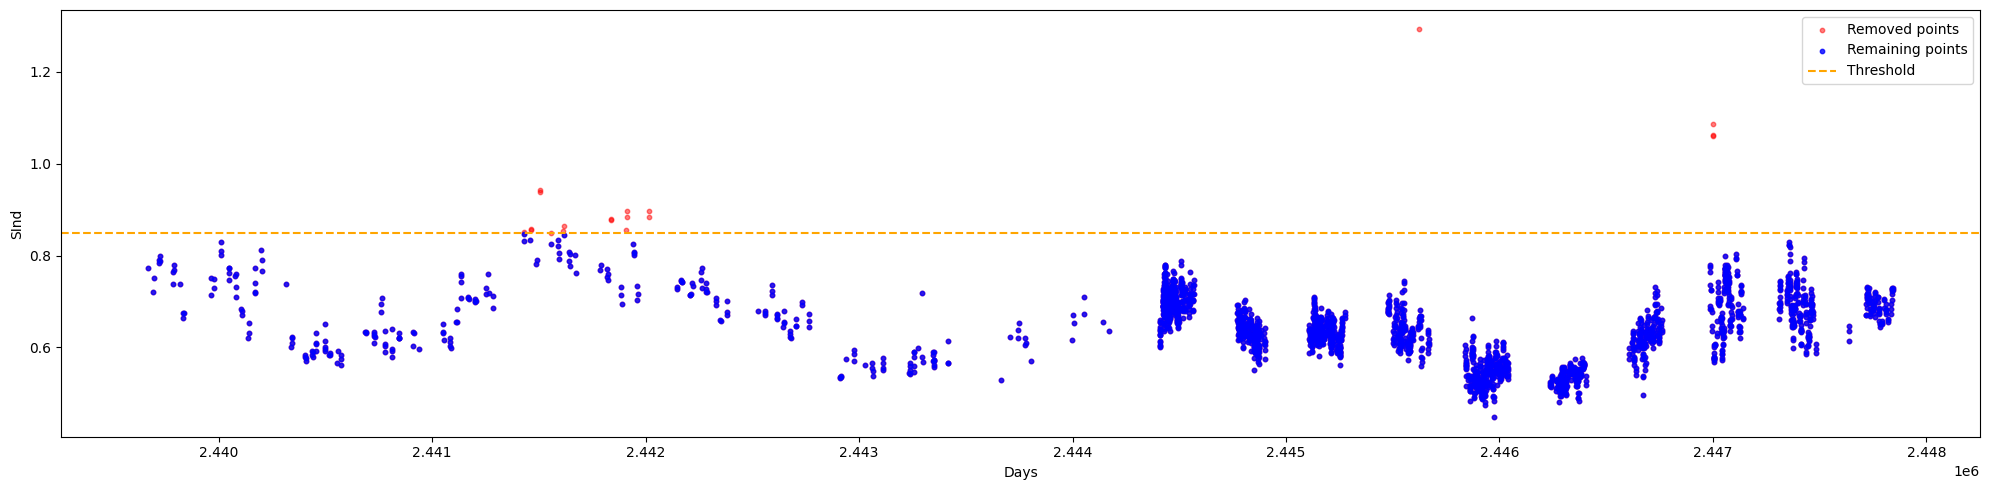

In [18]:
cleaned_HD201091 = clean_df(train_HD201091, tol = 4)


C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 2730.68 days was accepted.
In iteration 1, period at 12043.36 days was accepted.
Peak at period 1366.67 days was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.00.
In iteration 2, period at 505.26 days was accepted.
Peak at period 1377.25 days was identified to be an alias of 2730.68 days at mult 0.50 by tolerance 0.01.
In iteration 3, period at 290.64 days was accepted.
In iteration 4, period at 36.97 days was accepted.
Peak at period 2070.03 days was identified to be an alias of 505.26 days at mult 4.00 by tolerance 0.02.
In iteration 5, period at 443.94 days was accepted.
Peak at period 36.60 days was identified to be an alias of 36.97 days at mult 1.00 by tolerance 0.01.
In iteration 6, period at 39.89 days was accepted.
In iteration 7, period at 33.32 days was accepted.
Peak at period 156.32 days was identified to be an alias of 39.89 days at mult 4.00 by tolerance 0.02.
Peak at period 252.68 days was identified to be an alias of 50

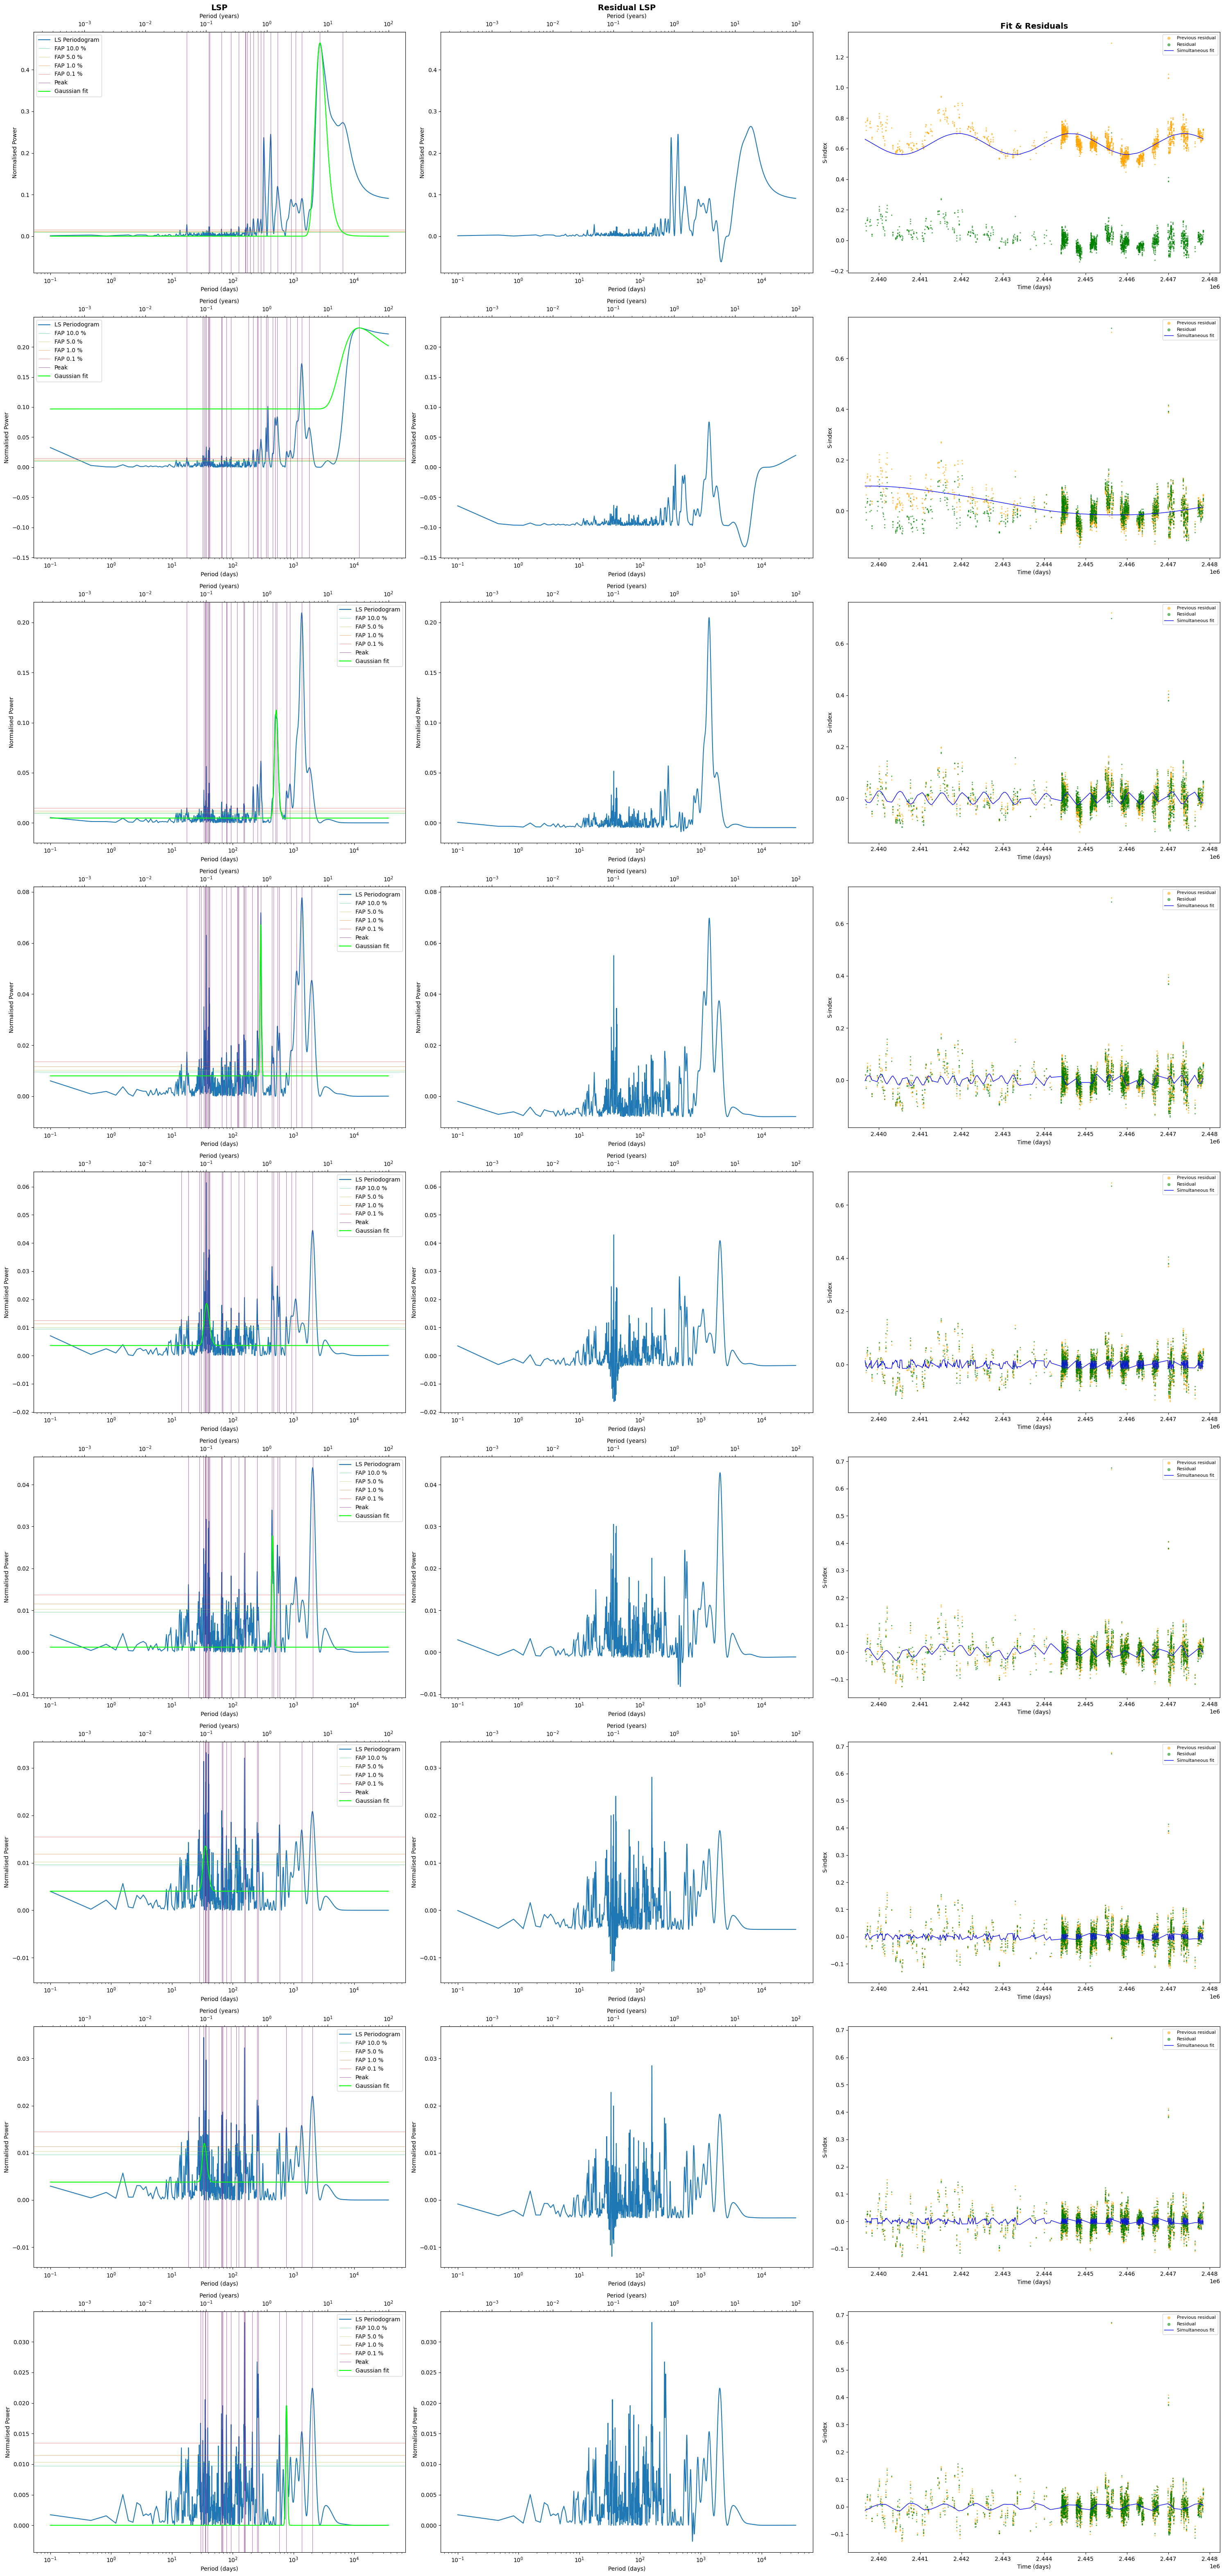

Accepted periods and their heights
+----------+-------+--------+--------------+
|   Days   | Years | Height |     SNR      |
+----------+-------+--------+--------------+
| 2730.68  |  7.48 | 0.4644 |   23570.79   |
| 12043.36 | 33.00 | 0.2316 | 117241745.13 |
|  505.26  |  1.38 | 0.1082 |    18.65     |
|  290.64  |  0.80 | 0.0718 |    10.01     |
|  36.97   |  0.10 | 0.0614 |     9.87     |
|  443.94  |  1.22 | 0.0339 |     7.53     |
|  39.89   |  0.11 | 0.0329 |     6.19     |
|  33.32   |  0.09 | 0.0345 |     7.37     |
|  762.59  |  2.09 | 0.0196 |    13.95     |
+----------+-------+--------+--------------+


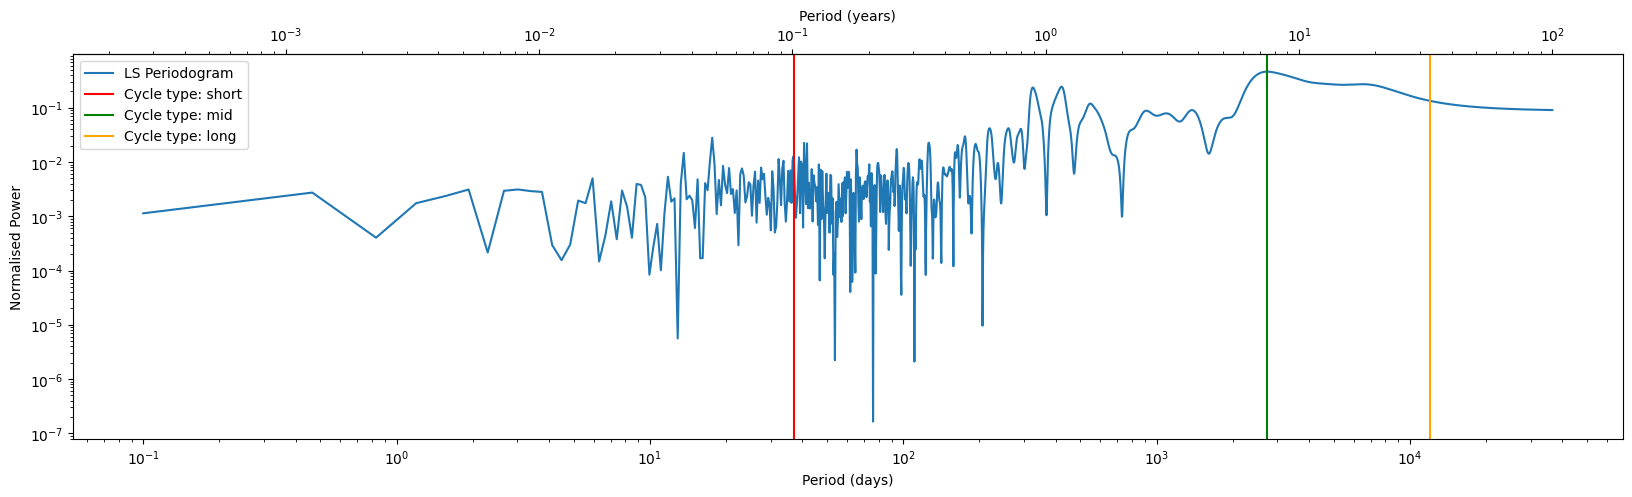

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|   Short    |   36.97    |     0.10    |
|    Mid     |  2730.68   |     7.48    |
|    Long    |  12043.36  |    33.00    |
+------------+------------+-------------+
+------------+------------+-------------+--------+
| Cycle Type | Prior Days | Prior Years | Source |
+------------+------------+-------------+--------+
|   Short    |   36.97    |     0.10    | found  |
|    Mid     |  2730.68   |     7.48    | found  |
|    Long    |  12043.36  |    33.00    | found  |
+------------+------------+-------------+--------+


In [19]:
classified_signal_data = find_classify_signals(train_HD201091)
priors = get_priors(classified_signal_data, 'G') 

- make it loop through k = 1,2,3

In [ ]:
train_df = cleaned_HD201091
valid_df = valid_HD201091
k = 3
error_percent = 2.5
train_yerr = train_df['sind'] * error_percent / 100
verbose = True

# Some key stats
mean_train = train_df['sind'].mean()
std_train = train_df['sind'].std()

#--------------------------------------------------------------

prior_combinations = {
    # Single kernels
    "1s":   (1, [priors['short']]),
    "1m":   (1, [priors['mid']]),
    "1l":   (1, [priors['long']]),

    # Pairs
    "2sm":  (2, [priors['short'], priors['mid']]),
    "2ml":  (2, [priors['mid'],   priors['long']]),
    "2ls":  (2, [priors['long'],  priors['short']]),

    # Triple
    "3sml": (3, [priors['short'], priors['mid'], priors['long']]),
}

# rho_bounds_map = {
#     priors['short']: (np.log(0.1),       np.log(200)),
#     priors['mid']:   (np.log(200),        np.log(20*365)),
#     priors['long']:  (np.log(20*365),     np.log(150*365)),
# }

#----------------------------------------------------------------


best_NLPD = np.inf  # lower is better
best_combo = "None"

for name, (k, prior_combo) in prior_combinations.items():
    np.random.seed(1701)
    # Set up initial guesses
    sigma_0s = [std_train/k for _ in range(k)] # Split the amplitudes evenly
    rho_0s = prior_combo
    q_0s = [np.random.uniform(0.5,1) for _ in range(k)] # Randomise them in the underdamped regime

    # The optimiser works in log space so initial guesses must be log
    initial_guess = np.concatenate([np.log(sigma_0s),
                                                    np.log(rho_0s),
                                                    np.log(q_0s)])

    # Create the optimisation bounds
    sigma_upper = 5 * std_train # this is a bit high but can be tweaked downwards
    sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for _ in range(k)]
    rho_bounds = [(np.log(rho * 0.9), np.log(rho * 1.1)) for rho in rho_0s]
    q_bounds = [(np.log(10),np.log(100)) for _ in range(k)]
    bounds = np.concatenate([sigma_bounds,
                                                    rho_bounds,
                                                    q_bounds])

    # Create the initial kernel
    kernel = terms.SHOTerm(sigma = sigma_0s[0],
                                            rho = rho_0s[0],
                                            Q = q_0s[0])
    for k_idx in range(1,k):
        kernel += terms.SHOTerm(sigma = sigma_0s[k_idx],
                                            rho = rho_0s[k_idx],
                                            Q = q_0s[k_idx])
        
    # Define the GP
    gp = celerite2.GaussianProcess(kernel, mean = mean_train)
    gp.compute(train_df['day'], yerr = train_yerr)

    # Train the GP
    gp_results = minimize(NLL, initial_guess,
                        args = (gp, k, train_df['sind'].to_numpy()),
                        method = 'L-BFGS-B',
                        bounds = bounds)
    gp = set_params(gp_results.x, k, gp)
    gp.recompute()
    best = np.exp(gp_results.x)

    # Print the best optimisation results
    if verbose:
        table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
        best_sigmas = best[0:k]
        best_rhos = best[k:2*k]
        best_qs = best[2*k:]

        for k_idx in range(k):
            table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",  f"{best_rhos[k_idx]:.2f}",  f"{best_rhos[k_idx]/365:.2f}"])
        print(gp_results.success, gp_results.message)
        print(f"For k = {k}")
        print(table)

    #---------Predict it forwards
    valid_df = valid_HD201091
    plot = True
    ax = None

    t_pred = valid_df['day']  # must match units used in gp.compute
    mu, cov = gp.predict(train_df['sind'], t = t_pred, return_var = True) 
    sigma = np.sqrt(cov)

    if plot:
        results = pd.DataFrame({
        'forecast' : mu,
        'lower'    : mu - sigma,
        'upper'    : mu + sigma,
        }, index=valid_df.index)

        if ax is None:
            fig, ax = plt.subplots(figsize=(20, 5))
        ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker = 'x')
        ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha = 0.5)
        fig.suptitle(name)

        ax.plot(valid_df['year'], results['forecast'], color='green', label='Predictions')
        ax.fill_between(valid_df['year'], results['lower'], results['upper'], color='green', alpha=0.2, label='Uncertainties')

        ax.legend()

    #---------------------- Model comparison
    y_valid = valid_df['sind'].to_numpy()
    valid_yerr = valid_df['sind'] * error_percent / 100

    total_var = cov + valid_yerr**2
    nlpd_per_point = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
    mean_nlpd = nlpd_per_point.mean()

    if mean_nlpd < best_NLPD:
        best_combo = name
        best_NLPD = mean_nlpd
        best_gp = gp        
        best_params = best   

    print(f"Mean NLPD on validation set ({name}): {mean_nlpd:.4f}")


True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
For k = 1
+--------+-------+------------+-------------+
| sigma  |   Q   | rho (days) | rho (years) |
+--------+-------+------------+-------------+
| 0.1742 | 10.00 |   35.17    |     0.10    |
+--------+-------+------------+-------------+
Mean NLPD on validation set (1s): -0.7870
True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
For k = 1
+--------+-------+------------+-------------+
| sigma  |   Q   | rho (days) | rho (years) |
+--------+-------+------------+-------------+
| 0.3572 | 10.00 |  2457.62   |     6.73    |
+--------+-------+------------+-------------+
Mean NLPD on validation set (1m): -0.4737
True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
For k = 1
+--------+-------+------------+-------------+
| sigma  |   Q   | rho (days) | rho (years) |
+--------+-------+------------+-------------+
| 0.3572 | 10.00 |  10839.03  |    29.70    |
+--------+-------+------------+-------------+
Mean NLPD on validation set (1

In [21]:
# train_df = train_HD201091 # at this point the outliers have already been eradicated

# error_percent = 5
# train_yerr = train_df['sind'] * error_percent / 100
# verbose = True

# # Some key stats
# mean_train = train_df['sind'].mean()
# std_train = train_df['sind'].std()

# #--------------------------------------------------------------

# prior_combinations = {
#     # Single kernels
#     "1s":   (1, [priors['short']]),
#     "1m":   (1, [priors['mid']]),
#     "1l":   (1, [priors['long']]),

#     # Pairs
#     "2sm":  (2, [priors['short'], priors['mid']]),
#     "2ml":  (2, [priors['mid'],   priors['long']]),
#     "2ls":  (2, [priors['long'],  priors['short']]),

#     # Triple
#     "3sml": (3, [priors['short'], priors['mid'], priors['long']]),
# }

# rho_bounds_map = {
#     priors['short']: (np.log(0.1),       np.log(200)),
#     priors['mid']:   (np.log(200),        np.log(20*365)),
#     priors['long']:  (np.log(20*365),     np.log(150*365)),
# }

# #----------------------------------------------------------------

# best_NLPD = np.inf  # lower is better
# best_combo = "None"

# for name, (k, prior_combo) in prior_combinations.items():
#     # Set up initial guesses
#     sigma_0s = [std_train/k for _ in range(k)] # Split the amplitudes evenly
#     rho_0s = prior_combo
#     q_0s = [np.random.uniform(0.5,1) for _ in range(k)] # Randomise them in the underdamped regime

#     # The optimiser works in log space so initial guesses must be log
#     initial_guess = np.concatenate([np.log(sigma_0s),
#                                                     np.log(rho_0s),
#                                                     np.log(q_0s)])

#     # Create the optimisation bounds
#     sigma_upper = 5 * std_train # this is a bit high but can be tweaked downwards
#     sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for _ in range(k)]
#     rho_bounds = [rho_bounds_map[r] for r in rho_0s]
#     q_bounds = [(np.log(0.5),np.log(10)) for _ in range(k)]
#     bounds = np.concatenate([sigma_bounds,
#                                                     rho_bounds,
#                                                     q_bounds])

#     # Create the initial kernel
#     kernel = terms.SHOTerm(sigma = sigma_0s[0],
#                                             rho = rho_0s[0],
#                                             Q = q_0s[0])
#     for k_idx in range(1,k):
#         kernel += terms.SHOTerm(sigma = sigma_0s[k_idx],
#                                             rho = rho_0s[k_idx],
#                                             Q = q_0s[k_idx])
        
#     # Define the GP
#     gp = celerite2.GaussianProcess(kernel, mean = mean_train)
#     gp.compute(train_df['day'], yerr = train_yerr)

#     # Train the GP
#     gp_results = minimize(NLL, initial_guess,
#                         args = (gp, k, train_df['sind'].to_numpy()),
#                         method = 'L-BFGS-B',
#                         bounds = bounds)
#     gp = set_params(gp_results.x, k, gp)
#     gp.recompute()
#     best = np.exp(gp_results.x)

#     # Print the best optimisation results
#     if verbose:
#         table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
#         best_sigmas = best[0:k]
#         best_rhos = best[k:2*k]
#         best_qs = best[2*k:]

#         for k_idx in range(k):
#             table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",  f"{best_rhos[k_idx]:.2f}",  f"{best_rhos[k_idx]/365:.2f}"])
#         print(gp_results.success, gp_results.message)
#         print(f"For k = {k}")
#         print(table)

#     #---------Predict it forwards
#     valid_df = valid_HD201091
#     plot = True
#     ax = None

#     t_pred = valid_df['day']  # must match units used in gp.compute
#     mu, cov = gp.predict(train_df['sind'], t = t_pred, return_var = True) 
#     sigma = np.sqrt(cov)

#     if plot:
#         results = pd.DataFrame({
#         'forecast' : mu,
#         'lower'    : mu - sigma,
#         'upper'    : mu + sigma,
#         }, index=valid_df.index)

#         if ax is None:
#             fig, ax = plt.subplots(figsize=(20, 5))
#         ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker = 'x')
#         ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha = 0.5)
#         fig.suptitle(name)

#         ax.plot(valid_df['year'], results['forecast'], color='green', label='Predictions')
#         ax.fill_between(valid_df['year'], results['lower'], results['upper'], color='green', alpha=0.2, label='Uncertainties')

#     #---------------------- Model comparison
#     y_valid = valid_df['sind'].to_numpy()
#     valid_yerr = valid_df['sind'] * error_percent / 100

#     total_var = cov + valid_yerr**2
#     nlpd_per_point = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
#     mean_nlpd = nlpd_per_point.mean()

#     if mean_nlpd < best_NLPD:
#         best_combo = name
#         best_NLPD = mean_nlpd

#     print(f"Mean NLPD on validation set ({name}): {mean_nlpd:.4f}")



In [27]:
best_combo

'3sml'

- This all seems above board. Now turn the whole process into a function in GPR9.